In [1]:
import numpy as np

N = 1000000

x = np.random.uniform(0, 1, N)
y = np.random.uniform(1, 2, N)
z = np.random.uniform(0, 3, N)

integral_mc = 3.0 * np.mean(x + y + z)
exact_val = 10.5

integral_mc, exact_val, abs(integral_mc - exact_val)

(np.float64(10.499110959748483), 10.5, np.float64(0.000889040251516704))

In [2]:
import numpy as np

N = 1000000

A = np.array([[0.2, 0.1], [0.1, 0.5]])
b = np.array([0.5, 0.6])
p_term = 1.0 - A.sum(axis=1)

def solve_mc(A, b, p_term, N):
    n = len(b)
    x = np.zeros(n)
    for i in range(n):
        state = np.full(N, i, dtype=int)
        score = np.zeros(N)
        active = np.ones(N, dtype=bool)
        while np.any(active):
            r = np.random.rand(N)
            term = active & (r >= 1 - p_term[state])
            score[term] += b[state[term]]
            active[term] = False
            step0 = active & (r < A[state, 0])
            step1 = active & (r >= A[state, 0]) & (r < A[state, 0] + A[state, 1])
            state[step0] = 0
            state[step1] = 1
        x[i] = np.mean(score)
    return x

x_mc = solve_mc(A, b, p_term, N)
x_exact = np.linalg.solve(np.eye(2) - A, b)

x_mc, x_exact, np.abs(x_mc - x_exact)

(array([0.5102857, 0.5820376]),
 array([0.79487179, 1.35897436]),
 array([0.28458609, 0.77693676]))

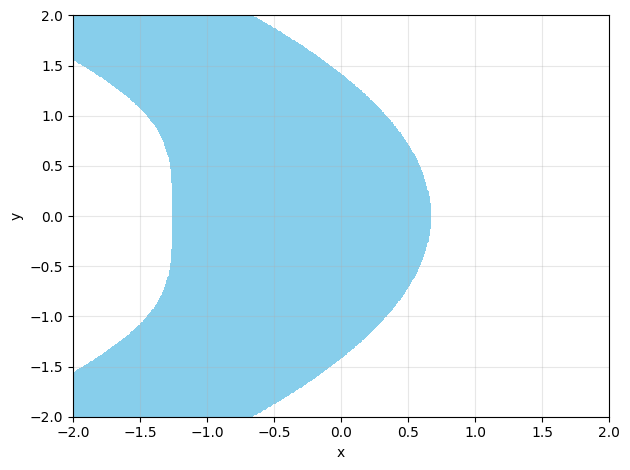

In [6]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000000

x_grid = np.linspace(-2, 2, 500)
y_grid = np.linspace(-2, 2, 500)
X, Y = np.meshgrid(x_grid, y_grid)
Z = ((-X**3 - Y**4 < 2) & (3*X + Y**2 < 2)).astype(float)

plt.contourf(X, Y, Z, levels=[0.5, 1.0], colors=['skyblue'])
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
from scipy.integrate import quad
import numpy as np

N = 1000000

x = np.random.uniform(-2, 2, N)
y = np.random.uniform(-2, 2, N)
cond = (-x**3 - y**4 < 2) & (3*x + y**2 < 2)
K = np.sum(cond)
S_mc = 16.0 * K / N

def integrand(y):
    right = (2 - y**2) / 3.0
    left = np.cbrt(-2 - y**4)
    return right - np.maximum(left, -2.0)

S_exact, _ = quad(integrand, -2, 2)

S_mc, S_exact, abs(S_mc - S_exact), abs(S_mc - S_exact) / S_exact

(np.float64(7.139328),
 7.136840714358558,
 np.float64(0.0024872856414415168),
 np.float64(0.00034851354275532094))